In [1]:
import matplotlib.pyplot as plt

from imagematerials.rest_of.metals_projections import (
    steel_projection, 
    aluminium_projection, 
    copper_projection)

from imagematerials.rest_of.water import water_consumption

from imagematerials.rest_of.biomass import biomass_data

from imagematerials.rest_of.fossil_fuels import fossil_fuel_data

from imagematerials.rest_of.const import get_key, DIM2_primary_dict

from imagematerials.rest_of.cement import cement_projection
from imagematerials.rest_of.sand import sand_projections


In [2]:

copper = copper_projection()
steel = steel_projection()
aluminium = aluminium_projection()


copper_regions
china
high
low
medium
all_regions
all_together
china
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
oceania
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.


In [3]:
electricity_wc, industrial_wc, municipality_wc = water_consumption()

In [4]:
(splitted_up_crops_total, splitted_up_crops_food, splitted_up_crops_feed,
splitted_up_crops_other_use, splitted_up_feed, splitted_up_wood, splitted_up_animal_products,
splitted_up_biofuel_crops) = biomass_data()

In [5]:
(fossils_primary, fossils_prim_per_sec, fossils_final,
fossils_primary_converted, fossils_primsecond_converted, 
fossils_final_converteted) = fossil_fuel_data()

In [6]:
# Add labels and title
fossils_primary_converted = fossils_primary_converted.loc[:, 28].unstack() # unstacks second index (primary energy types)
fossils_primary_converted.index.get_level_values(0).unique()

Index([1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980,
       ...
       2091, 2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100],
      dtype='int64', name='time', length=130)

In [7]:
# total values

copper_total = copper.projection_per_region_total.sum(axis = 1)/1000_000 + copper.image_mat_data.sum(axis = 1)/1000_000
aluminium_total = aluminium.projection_per_region_total.sum(axis = 1)/1000_000 + aluminium.image_mat_data.sum(axis = 1)/1000_000
steel_total = steel.projection_per_region_total.sum(axis = 1)/1000_000 + steel.image_mat_data.sum(axis = 1)/1000_000


In [8]:
cement = cement_projection()
sand = sand_projections()

all
Canada
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
China
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Average
Lower
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
Japan
limited growth model Optimal parameters not found: Number of calls to function has reached maxfev = 800.
High


In [9]:
cement_total = cement.projection_per_region_total.sum(axis = 1)/1000_000 + cement.image_mat_data.sum(axis = 1)/1000_000
sand_total = sand.projection_per_region_total.sum(axis = 1)/1000_000 + sand.image_mat_data.sum(axis = 1)/1000_000


C:\Users\Arp00003\AppData\Local\Temp\ipykernel_14468\1978813599.py:83: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax3.legend(loc = 'upper left')


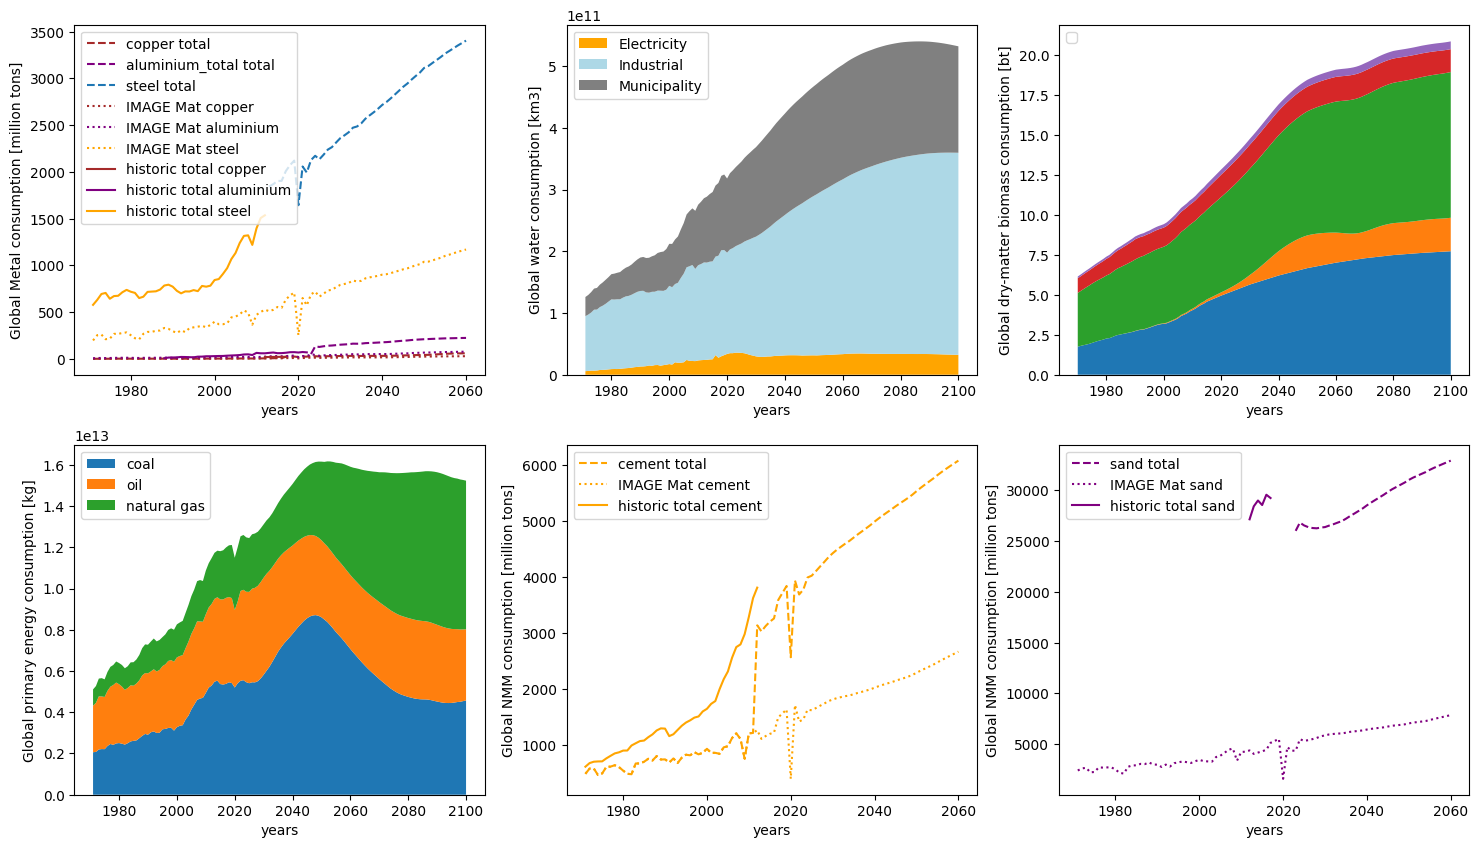

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10), sharey=False)

# First row axes
ax1, ax2, ax3 = axes[0]

# Second row axes
ax4, ax5, ax6 = axes[1]  # ax6 can remain empty or be hidden


ax1.plot(copper_total.loc[1971:2060],
        label = 'copper total', 
        linestyle = '--',
        color = 'brown')
ax1.plot(aluminium_total.loc[2023:2060],
        label = 'aluminium_total total', 
        linestyle = '--',
        color = 'purple')
ax1.plot(steel_total.loc[2013:2060],
        label = 'steel total', 
        linestyle = '--')

ax1.plot(copper.image_mat_data.loc[1971:2060].sum(axis = 1)/1000_000, 
        label = 'IMAGE Mat copper',
        color = 'brown',
        linestyle = ':')
ax1.plot(aluminium.image_mat_data.loc[1971:2060].sum(axis = 1)/1000_000,
        label = 'IMAGE Mat aluminium',
        color = 'purple',
        linestyle = ':')
ax1.plot(steel.image_mat_data.loc[1971:2060].sum(axis = 1)/1000_000,
        label = 'IMAGE Mat steel',
        color = 'orange',
        linestyle = ':')

ax1.plot(copper.historic_consumption_data.sum(axis = 1)/1000_000, 
        label = 'historic total copper',
        color = 'brown')
ax1.plot(aluminium.historic_consumption_data.loc[:2022].sum(axis = 1)/1000_000, 
        label = 'historic total aluminium',
        color = 'purple')
ax1.plot(steel.historic_consumption_data.sum(axis = 1)/1000_000, 
        label = 'historic total steel',
        color = 'orange')

ax1.set_xlabel('years')
ax1.set_ylabel('Global Metal consumption [million tons]')
ax1.legend(loc = 'upper left')

ax2.stackplot(
    electricity_wc.index, #years
    electricity_wc.loc[:, 28],
    industrial_wc.loc[:, 28],
    municipality_wc.loc[:, 28],
    labels=['Electricity', 'Industrial', 'Municipality'],
    colors=['orange', 'lightblue', 'gray'])

ax2.set_xlabel('years')
ax2.set_ylabel('Global water consumption [km3]')
ax2.legend(loc = 'upper left')

splitted_up_crops_total.get('total').loc[:, 27]

ax3.stackplot(
    splitted_up_crops_total.get('total').index, #years
    splitted_up_crops_total.get('total').loc[:, 27],
    splitted_up_biofuel_crops.get('total biofuel').loc[:, 27],
    splitted_up_feed.get('total').loc[:, 27],
    splitted_up_wood.get('total wood IMAGE').loc[:, 27],
#     splitted_up_wood.get('wood buildings (BUMA)').loc[:, '27'],
    splitted_up_animal_products.get('animal products total').loc[:, 27])
    


labels=['Crops', 'Feed', 'Wood', 'Animal Products', 'Biofuel'],
colors = ['#1f77b4',  # blue
        '#ff7f0e',  # orange
        '#2ca02c',  # green
        '#d62728',  # red
        '#9467bd']  # purple

ax3.set_xlabel('years')
ax3.set_ylabel('Global dry-matter biomass consumption [bt]')
ax3.legend(loc = 'upper left')

# define labels via dict
labels = [get_key(i, DIM2_primary_dict) for i in list(fossils_primary_converted.columns)]

ax4.stackplot(fossils_primary_converted.index.get_level_values(0).unique(), 
              fossils_primary_converted.loc[:, 1], 
              fossils_primary_converted.loc[:, 2], 
              fossils_primary_converted.loc[:, 4],
              labels = labels)
ax4.set_xlabel('years')
ax4.set_ylabel('Global primary energy consumption [kg]')
ax4.legend(loc = 'upper left')

ax5.plot(cement_total.loc[1971:2060],
        label = 'cement total', 
        linestyle = '--',
        color = 'orange')
ax6.plot(sand_total.loc[2023:2060],
        label = 'sand total', 
        linestyle = '--',
        color = 'purple')

ax5.plot(cement.image_mat_data.loc[1971:2060].sum(axis = 1)/1000_000, 
        label = 'IMAGE Mat cement',
        color = 'orange',
        linestyle = ':')
ax6.plot(sand.image_mat_data.loc[1971:2060].sum(axis = 1)/1000_000,
        label = 'IMAGE Mat sand',
        color = 'purple',
        linestyle = ':')

ax5.plot(cement.historic_consumption_data.sum(axis = 1)/1000_000, 
        label = 'historic total cement',
        color = 'orange')
ax6.plot(sand.historic_consumption_data.loc[:2022].sum(axis = 1)/1000_000, 
        label = 'historic total sand',
        color = 'purple')

ax5.set_xlabel('years')
ax5.set_ylabel('Global NMM consumption [million tons]')
ax5.legend(loc = 'upper left')

ax6.set_xlabel('years')
ax6.set_ylabel('Global NMM consumption [million tons]')
ax6.legend(loc = 'upper left')

In [11]:
electricity_wc.loc[:, 28]

time
1971    5.780593e+09
1972    6.087280e+09
1973    6.715388e+09
1974    6.631647e+09
1975    6.900670e+09
            ...     
2096    3.273964e+10
2097    3.260553e+10
2098    3.245235e+10
2099    3.232322e+10
2100    3.219412e+10
Name: 28, Length: 130, dtype: float64

In [12]:
# ax.stackplot(
#     copper.projection_per_region_total.index, # years
#     copper.projection_per_region_total.sum(axis = 1)/1000_000,
#     aluminium.projection_per_region_total.sum(axis = 1)/1000_000,
#     steel.projection_per_region_total.sum(axis = 1)/1000_000,
#     labels=['Copper', 'Aluminium', 'Steel']
# )